In [ ]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pickle
import os
BASE_DIR = "/capstor/store/cscs/swissai/infra01/apertus_probes"


: 

In [ ]:
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
import colorsys

def _adjust_lightness(color, factor=1.0):
    """factor > 1 -> lighter, < 1 -> darker."""
    rgb = mcolors.to_rgb(color)
    h, l, s = colorsys.rgb_to_hls(*rgb)
    l = max(0, min(1, l * factor))
    return colorsys.hls_to_rgb(h, l, s)

def plot_rmse_comparison_multi(
    results_by_llm: dict,
    models_to_plot,
    token_positions,
    title_suffix: str = ""
):
    plt.figure(figsize=(14, 6))

    # Base colors per LLM
    llm_base_color = {
        "Apertus-8B-Instruct-2509": "tab:orange",
        "Llama-3.1-8B-Instruct": "tab:blue",
    }
    llm_label = {
        "Apertus-8B-Instruct-2509": "Apertus",
        "Llama-3.1-8B-Instruct": "Llama",
    }

    # Lightness factor per probe model
    probe_lightness = {
        "L-0.1": 0.9,   # slightly darker
        "L-0.25": 1.2,  # slightly lighter
    }

    # ---------- PLOT LINES ----------
    for llm_name, df in results_by_llm.items():
        base = llm_base_color.get(llm_name, "black")

        for model in models_to_plot:
            light_factor = probe_lightness.get(model, 1.0)
            color = _adjust_lightness(base, light_factor)

            for token_pos in token_positions:
                mask = (df["Model"] == model) & (df["Token-Pos"] == token_pos)
                group = df[mask]
                if group.empty:
                    continue

                layer_averages = group.groupby("Layer")[["RMSE", "Dummy-RMSE"]].mean()

                # RMSE: solid
                plt.plot(
                    layer_averages.index,
                    layer_averages["RMSE"],
                    color=color,
                    linestyle="-",
                    linewidth=2.0,
                    alpha=1.0,
                )
                # Dummy-RMSE: dashed
                plt.plot(
                    layer_averages.index,
                    layer_averages["Dummy-RMSE"],
                    color=color,
                    linestyle="--",
                    linewidth=1.5,
                    alpha=0.9,
                )

    ax = plt.gca()

    # ---------- SINGLE LEGEND ----------
    legend_handles = []
    legend_labels = []

    # One solid line per (LLM, probe model) combo
    for llm_name in results_by_llm.keys():
        base = llm_base_color.get(llm_name, "black")
        for model in models_to_plot:
            light_factor = probe_lightness.get(model, 1.0)
            color = _adjust_lightness(base, light_factor)
            legend_handles.append(
                Line2D([0], [0], color=color, linestyle="-", linewidth=2.0)
            )
            legend_labels.append(f"{llm_label[llm_name]} {model}")

    # One dashed line entry explaining the dummy
    legend_handles.append(
        Line2D([0], [0], color="black", linestyle="--", linewidth=1.8)
    )
    legend_labels.append("Dummy RMSE")

    ax.legend(
        legend_handles,
        legend_labels,
        fontsize=10,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0.0,
        title=None,       # or "Lines" if you want a title
        frameon=True,
    )

    # ---------- STYLING ----------
    plt.title(title_suffix, fontsize=16, pad=14)
    plt.xlabel("Layer", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout(rect=[0, 0, 0.8, 1])
    plt.show()


: 

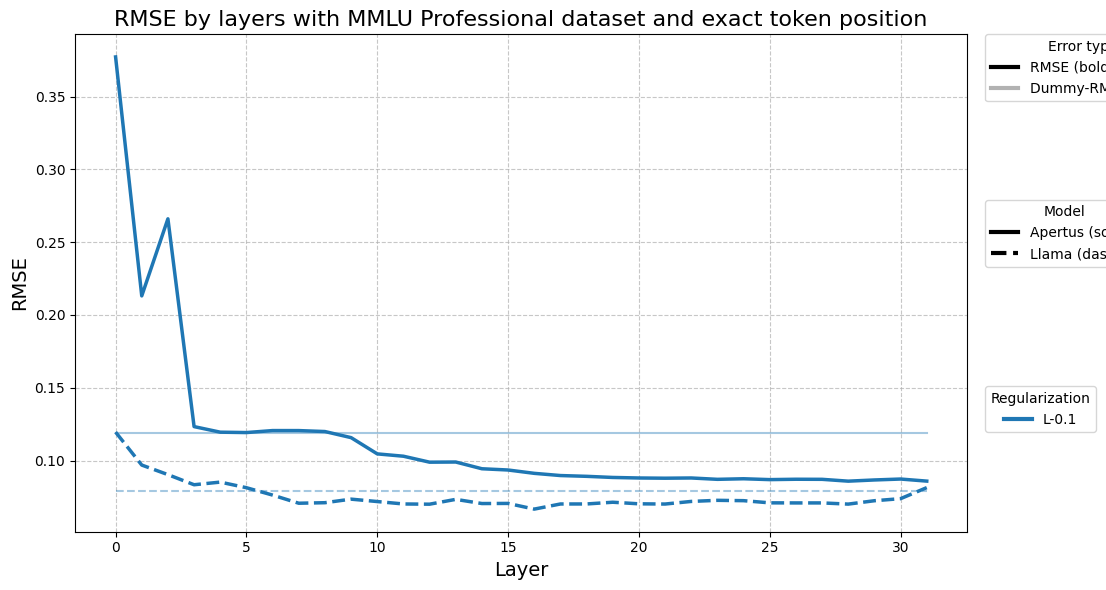

In [18]:
dataset_name = "mmlu_professional"   # or mmlu_professional / ARC-Challenge / ARC-Easy
dataset_in_title = "MMLU Professional"
variant = "leave"                   # or "transform"
paths = get_paths_for_dataset(dataset_name, variant=variant)
results_by_llm = {model: load_pkl(p) for model, p in paths.items()}

models_to_plot = ["L-0.1"]
# exact position
plot_rmse_comparison_multi(
    results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["exact"],
    title_suffix=f"RMSE by layers with {dataset_in_title} dataset and exact token position",
)


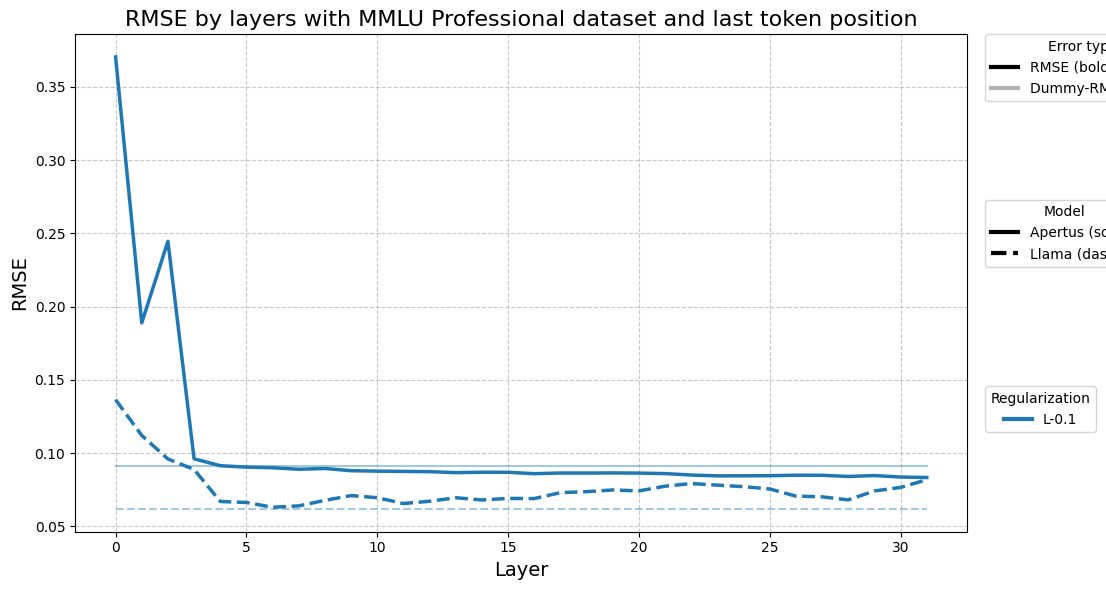

In [19]:
# last token
plot_rmse_comparison_multi(
    results_by_llm,
    models_to_plot=models_to_plot,
    token_positions=["last"],
    title_suffix=f"RMSE by layers with {dataset_in_title} dataset and last token position",
)